## Regression Analysis

This section uses linear regression to examine the relationship between physical activity and BMI percentile.

The dependent variable is `BMIPercentile`, and the main independent variable is `PhysicalActivityDays`.

Two regression models are used:

1. Simple linear regression  
   - BMI percentile is predicted by physical activity days only.

2. Multiple linear regression  
   - BMI percentile is predicted by physical activity days, while also controlling for sex and grade.

The purpose of this analysis is to determine whether physical activity days are associated with BMI percentile among high school students.

First five rows:
   PhysicalActivityDays  BMIPercentile     Sex       Grade
0                   1.0      66.531824    Male  10th grade
1                   0.0      98.174319  Female   9th grade
2                   0.0      33.075531  Female  11th grade
3                   6.0      45.688334  Female  11th grade
4                   5.0      62.390331  Female  11th grade

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12874 entries, 0 to 12873
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PhysicalActivityDays  12874 non-null  float64
 1   BMIPercentile         12874 non-null  float64
 2   Sex                   12874 non-null  object 
 3   Grade                 12874 non-null  object 
dtypes: float64(2), object(2)
memory usage: 402.4+ KB
None

Simple Linear Regression Result:
                            OLS Regression Results                            
Dep. Variable:          

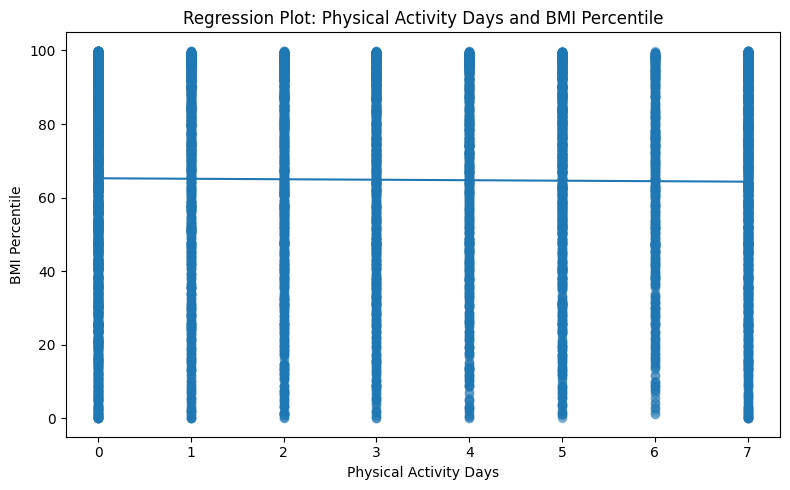


Regression analysis completed.
Regression results saved to:
C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output\regression

Regression figure saved to:
C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output\figures


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import statsmodels.formula.api as smf

# 讀取清理後資料
processed_path = r"C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\data\data processed\cleaned_yrbs_physical_activity_bmi.csv"

# output 主資料夾
output_dir = r"C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output"

# output 裡面的分類資料夾
figures_dir = os.path.join(output_dir, "figures")
tables_dir = os.path.join(output_dir, "tables")
regression_dir = os.path.join(output_dir, "regression")

# 自動建立資料夾
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(regression_dir, exist_ok=True)

# 讀取資料
data = pd.read_csv(processed_path)

# 檢查資料
print("First five rows:")
print(data.head())

print("\nData information:")
print(data.info())

# --------------------------------------------------
# Model 1: Simple Linear Regression
# --------------------------------------------------

model_simple = smf.ols(
    "BMIPercentile ~ PhysicalActivityDays",
    data=data
).fit()

print("\nSimple Linear Regression Result:")
print(model_simple.summary())

# 儲存簡單回歸結果
with open(
    os.path.join(regression_dir, "simple_regression_summary.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(model_simple.summary().as_text())

# --------------------------------------------------
# Model 2: Multiple Linear Regression
# --------------------------------------------------

model_multiple = smf.ols(
    "BMIPercentile ~ PhysicalActivityDays + C(Sex) + C(Grade)",
    data=data
).fit()

print("\nMultiple Linear Regression Result:")
print(model_multiple.summary())

# 儲存多元回歸結果
with open(
    os.path.join(regression_dir, "multiple_regression_summary.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(model_multiple.summary().as_text())

# --------------------------------------------------
# Save Coefficient Table
# --------------------------------------------------

coef_table = pd.DataFrame({
    "Variable": model_multiple.params.index,
    "Coefficient": model_multiple.params.values,
    "P_Value": model_multiple.pvalues.values
})

coef_table.to_csv(
    os.path.join(regression_dir, "multiple_regression_coefficients.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\nRegression coefficient table:")
print(coef_table)

# --------------------------------------------------
# Regression Plot
# --------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(
    data["PhysicalActivityDays"],
    data["BMIPercentile"],
    alpha=0.3
)

# 取得簡單回歸預測線
x_values = sorted(data["PhysicalActivityDays"].unique())
prediction_data = pd.DataFrame({
    "PhysicalActivityDays": x_values
})
y_values = model_simple.predict(prediction_data)

plt.plot(x_values, y_values)

plt.xlabel("Physical Activity Days")
plt.ylabel("BMI Percentile")
plt.title("Regression Plot: Physical Activity Days and BMI Percentile")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "regression_physical_activity_bmi.png"),
    dpi=300
)

plt.show()

print("\nRegression analysis completed.")
print("Regression results saved to:")
print(regression_dir)
print("\nRegression figure saved to:")
print(figures_dir)

## Results and Interpretation

The multiple linear regression model was used to examine the relationship between physical activity days and BMI percentile, while controlling for sex and grade.

The result shows that the p-value for `PhysicalActivityDays` is 0.0012, which is less than 0.05. Therefore, physical activity days are statistically significantly associated with BMI percentile.

The coefficient of `PhysicalActivityDays` is -0.3129. This means that for each additional day of physical activity, BMI percentile decreases by about 0.31 points on average, after controlling for sex and grade.

Although the relationship is statistically significant, the size of the effect is small. This suggests that physical activity is related to BMI percentile, but it may not be the only important factor affecting BMI among high school students.

## Conclusion

This project investigated whether physical activity affects BMI percentile among high school students using the 2007 YRBS dataset.

Based on the regression result, physical activity days have a statistically significant negative relationship with BMI percentile. Students who were physically active more often tended to have slightly lower BMI percentile.

However, the effect size was small, so the result should be interpreted carefully. Other factors, such as diet, sleep, sex, grade level, and lifestyle habits, may also influence BMI percentile.

Overall, the analysis suggests that physical activity is significantly associated with BMI percentile, but it is only one part of a broader health behavior pattern.